# 15 --- Gradual Degradation and Multi-Signal Detection

**Research context.**  Every fault so far has been a **step**: nominal one timestep, faulted the next.  Real actuators rarely fail this way --- bearings wear, motor windings degrade, thruster nozzles erode.  The fault is a *drift*, not a jump.  This matters for detection in a fundamental way:

- A **step fault** produces a sharp change-point --- exactly what a sliding-window z-test is designed for.
- A **drift** produces a slowly accumulating deviation that a change-point detector may *track* rather than *detect*: if the reference window adapts (or the deviation per-window is small), the fault stays below threshold at every individual moment while the system degrades continuously.  This is the classic *boiling-frog problem* of statistical process control.

**Physical analogue (thesis motivation, one paragraph in the paper):**  Gate fidelities in NISQ quantum devices drift continuously between calibrations rather than failing abruptly; a controller that can flag its own fidelity drift from internal signals --- without interrupting computation for a calibration cycle --- is the quantum-control analogue of the self-detection problem studied here.  The gradual-fault model $g(t)$ makes this analogy structural rather than rhetorical.

**Research questions for this notebook:**
- **A (tolerance):** How does each agent's return degrade under drifting faults, as a function of drift rate?
- **B (detection latency):** How long after onset does detection fire, and how does latency scale with drift rate?  Is there a drift rate below which the fault is *never* detected before episode end?
- **C (signal choice):** Is the value function the best detection signal?  We compare $V(s)$ / $Q_{\min}$ against policy entropy and TD error --- if entropy detects what value misses (especially for SAC), the tolerance-detectability tradeoff is *signal-dependent* rather than fundamental.

**Dependencies:**  `GradualFaultWrapper` + `GradualFaultSpec` (added to `src/envs/wrappers.py`), trained models, `src/self_detection.py`.

## 15.1  Setup

In [1]:
import sys, pathlib, glob, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings('ignore')

REPO = pathlib.Path.cwd().parent / 'py'
if not REPO.exists():
    REPO = pathlib.Path.cwd()
sys.path.insert(0, str(REPO))
LOGS = REPO / 'logs'
RUNS = REPO / 'runs'

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 300, 'font.size': 11,
    'axes.titlesize': 12, 'axes.labelsize': 11, 'axes.spines.top': False,
    'axes.spines.right': False, 'legend.frameon': False,
})

COLOURS = {'PPO': '#1f77b4', 'SAC': '#2ca02c', 'PPO_DR': '#ff7f0e'}
MARKERS = {'PPO': 'o', 'SAC': 's', 'PPO_DR': '^'}
SEEDS = [0, 1, 2, 3, 4]

## 15.2  The degradation model

Two drift profiles, both starting at onset step $t_0$ with $g(t) = 1$ for $t < t_0$:

**Linear ramp** (constant wear rate --- e.g. abrasive bearing wear):

$$g(t) = \max\!\big(g_{\min},\; 1 - r\,(t - t_0)\big)$$

**Exponential decay** (rate proportional to remaining capacity --- e.g. capacity fade, fidelity drift):

$$g(t) = g_{\min} + (1 - g_{\min})\, e^{-\lambda (t - t_0)}$$

The linear profile reaches $g = 0.5$ at $t_0 + 1/(2r)$; the exponential reaches the same at $t_0 + \ln 2 / \lambda$ (for $g_{\min}=0$).  **Matched-severity comparison:** to compare profiles fairly we match the *time to half-degradation* $t_{1/2}$, i.e. choose $\lambda = 2 r \ln 2$.

**Detection latency** is defined against onset (the earliest a detector could conceivably respond):

$$L = t_{\text{detect}} - t_0$$

and reported alongside the *gain at detection* $g(t_{\text{detect}})$ --- the operationally meaningful number: how much capability had already been lost when the alarm fired.  A detector with 50-step latency at $r = 0.01$ fires at $g = 0.5$ (half the thrust already gone); the same latency at $r = 0.001$ fires at $g = 0.95$ (early warning).  Latency alone is meaningless without the drift rate.

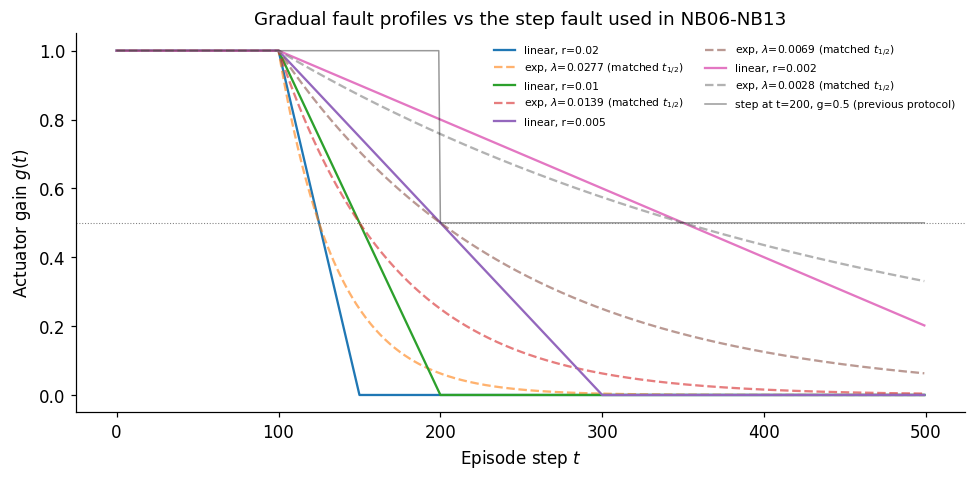

In [2]:
from src.envs.wrappers import GradualFaultSpec, GradualFaultWrapper, WrapperStack

# Visualise the fault profiles under study
fig, ax = plt.subplots(figsize=(9, 4.5))
t = np.arange(0, 500)
T0 = 100
RATES = [0.02, 0.01, 0.005, 0.002]
for r in RATES:
    spec = GradualFaultSpec(onset_step=T0, profile='linear', rate=r)
    ax.plot(t, [spec.gain_at(int(s)) for s in t], label=f'linear, r={r}')
    lam = 2 * r * np.log(2)
    spec_e = GradualFaultSpec(onset_step=T0, profile='exponential', rate=lam)
    ax.plot(t, [spec_e.gain_at(int(s)) for s in t], ls='--', alpha=0.6,
            label=f'exp, $\\lambda$={lam:.4f} (matched $t_{{1/2}}$)')
# step fault for reference
ax.plot(t, np.where(t < 200, 1.0, 0.5), color='k', lw=1, alpha=0.4,
        label='step at t=200, g=0.5 (previous protocol)')
ax.axhline(0.5, color='grey', ls=':', lw=0.7)
ax.set_xlabel('Episode step $t$')
ax.set_ylabel('Actuator gain $g(t)$')
ax.set_title('Gradual fault profiles vs the step fault used in NB06-NB13')
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(LOGS / 'nb15_fault_profiles.png', bbox_inches='tight')
plt.show()

## 15.3  Load models

In [3]:
from stable_baselines3 import PPO, SAC
from src.envs.lunarlander_factory import make_single_eval_env

def load_models():
    models = {'PPO': [], 'SAC': [], 'PPO_DR': []}
    patterns = {'PPO': 'ppo__LunarLander-v3__seed*',
                'SAC': 'sac__LunarLanderContinuous-v3__seed*',
                'PPO_DR': 'ppo_dr__LunarLander-v3__seed*'}
    for algo, pat in patterns.items():
        for run_dir in sorted(glob.glob(str(RUNS / pat))):
            run = pathlib.Path(run_dir)
            zips = list(run.glob('*.zip'))
            if zips:
                seed = int(run.name.split('seed')[1].split('__')[0])
                cls = SAC if algo == 'SAC' else PPO
                models[algo].append((seed, cls.load(zips[0], device='cpu')))
        print(f'{algo}: {len(models[algo])} seeds')
    return models

MODELS = load_models()
ENV_IDS = {'PPO': 'LunarLander-v3', 'SAC': 'LunarLanderContinuous-v3', 'PPO_DR': 'LunarLander-v3'}

PPO: 5 seeds
SAC: 5 seeds
PPO_DR: 5 seeds


## 15.4  Experiment A --- tolerance under drift

Linear ramps at four rates, onset $t_0 = 100$ (early enough that most episodes experience substantial drift --- see NB13's escape-probability analysis for why this matters).

In [4]:
def run_gradual_episodes(model, env_id, n_episodes, seed, spec):
    '''Run episodes under a gradual fault; track per-step gain for analysis.'''
    stack = WrapperStack(gradual_fault=spec)
    env = make_single_eval_env(env_id, seed=seed, wrapper_stack=stack, add_monitor=False)
    rows = []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep * 1000)
        done, ep_ret, ep_len = False, 0.0, 0
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, term, trunc, _ = env.step(action)
            ep_ret += float(r); ep_len += 1
            done = term or trunc
        # final gain reached in this episode
        final_g = spec.gain_at(ep_len - 1)
        rows.append({'episode': ep, 'return': ep_ret, 'length': ep_len,
                     'final_gain': final_g})
    env.close()
    return pd.DataFrame(rows)

T0 = 100
RATES = [0.02, 0.01, 0.005, 0.002]
N_EP = 20

t0c = time.time()
rows = []
for algo in ['PPO', 'SAC', 'PPO_DR']:
    drop = 2 if algo != 'SAC' else None
    for r in RATES:
        spec = GradualFaultSpec(onset_step=T0, profile='linear', rate=r,
                                g_min=0.0, discrete_drop_action=drop)
        for seed, model in MODELS[algo]:
            df = run_gradual_episodes(model, ENV_IDS[algo], N_EP, seed, spec)
            for _, row in df.iterrows():
                rows.append({'algo': algo, 'rate': r, 'seed': seed, **row.to_dict()})
        m = np.mean([x['return'] for x in rows if x['algo']==algo and x['rate']==r])
        print(f'{algo} r={r}: mean return = {m:.0f} ({time.time()-t0c:.0f}s)')

drift_df = pd.DataFrame(rows)
drift_df.to_csv(LOGS / 'nb15_drift_tolerance.csv', index=False)

PPO r=0.02: mean return = -49 (2s)
PPO r=0.01: mean return = -19 (4s)
PPO r=0.005: mean return = 38 (6s)
PPO r=0.002: mean return = 218 (9s)
SAC r=0.02: mean return = 158 (11s)
SAC r=0.01: mean return = 231 (13s)
SAC r=0.005: mean return = 248 (16s)
SAC r=0.002: mean return = 248 (18s)
PPO_DR r=0.02: mean return = -92 (20s)
PPO_DR r=0.01: mean return = -84 (22s)
PPO_DR r=0.005: mean return = -62 (24s)
PPO_DR r=0.002: mean return = -26 (28s)


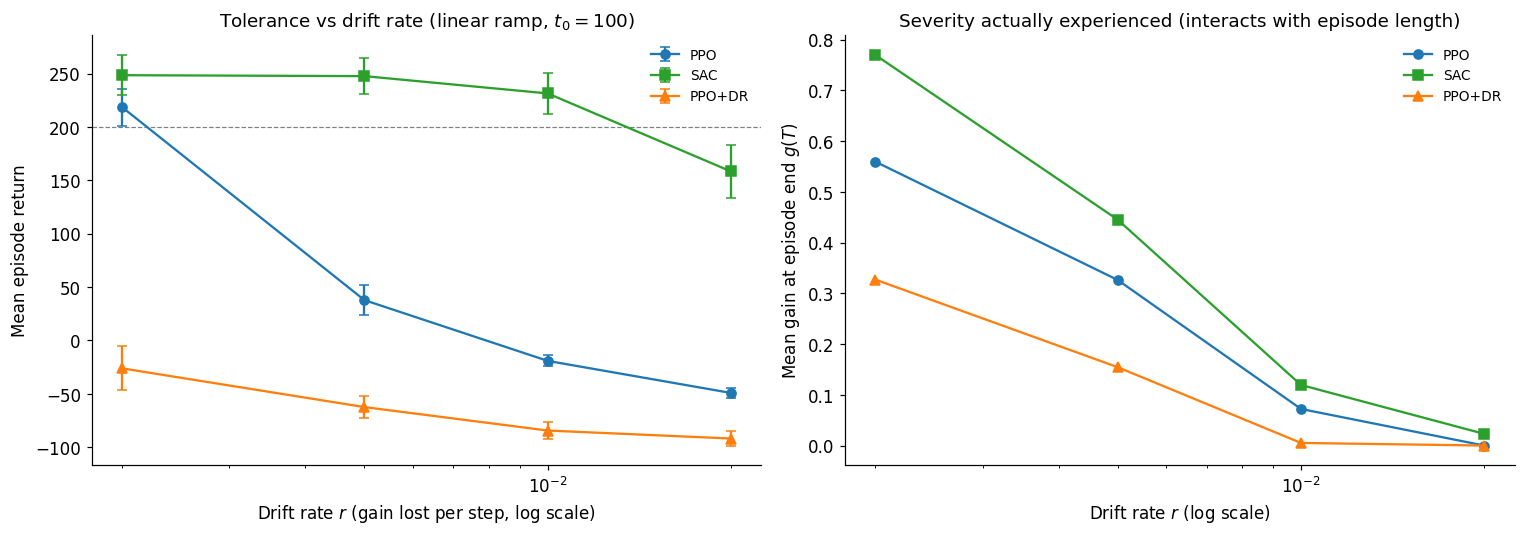

In [5]:
# --- Tolerance vs drift rate ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for algo in ['PPO', 'SAC', 'PPO_DR']:
    sub = drift_df[drift_df['algo'] == algo]
    means = sub.groupby('rate')['return'].mean()
    sems = sub.groupby('rate')['return'].sem()
    ax.errorbar(means.index, means.values, yerr=1.96*sems.values,
                color=COLOURS[algo], marker=MARKERS[algo], capsize=3,
                label=algo.replace('_', '+'))
ax.set_xscale('log')
ax.axhline(200, color='grey', ls='--', lw=0.8)
ax.set_xlabel('Drift rate $r$ (gain lost per step, log scale)')
ax.set_ylabel('Mean episode return')
ax.set_title('Tolerance vs drift rate (linear ramp, $t_0 = 100$)')
ax.legend(fontsize=9)

# Right: how much gain remained at episode end (drift severity actually experienced)
ax = axes[1]
for algo in ['PPO', 'SAC', 'PPO_DR']:
    sub = drift_df[drift_df['algo'] == algo]
    means = sub.groupby('rate')['final_gain'].mean()
    ax.plot(means.index, means.values, color=COLOURS[algo], marker=MARKERS[algo],
            label=algo.replace('_', '+'))
ax.set_xscale('log')
ax.set_xlabel('Drift rate $r$ (log scale)')
ax.set_ylabel('Mean gain at episode end $g(T)$')
ax.set_title('Severity actually experienced (interacts with episode length)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(LOGS / 'nb15_drift_tolerance.png', bbox_inches='tight')
plt.show()

## 15.5  Experiment B --- detection latency under drift

For each drift rate, run the nominal-relative z-test online and record the *first firing step* per episode.  Report:

- **Detection rate**: fraction of drift episodes where the detector fires at all (before episode end);
- **Latency** $L = t_{\text{detect}} - t_0$ over detected episodes;
- **Gain at detection** $g(t_{\text{detect}})$ --- the operational early-warning metric.

**The boiling-frog hypothesis:** below some critical drift rate $r^*$, per-window deviations stay under threshold and the fault is never flagged --- detection rate should collapse as $r \to 0$, *even though slow drifts are exactly the ones where early warning is most valuable*.  Locating $r^*$ for PPO+DR quantifies the practical limit of change-point-based self-detection.

In [6]:
from src.self_detection import extract_ppo_signals, extract_sac_signals

# NOTE: extract_*_signals inject a STEP fault internally. For gradual faults we
# need signal extraction under the GradualFaultWrapper, so we roll a local
# extractor that reuses the models' internals directly.
import torch

def extract_signals_gradual(algo, model, env_id, spec, n_episodes, seed):
    '''Per-step internal signals under a gradual fault. Returns long DataFrame.'''
    stack = WrapperStack(gradual_fault=spec) if spec is not None else None
    env = make_single_eval_env(env_id, seed=seed, wrapper_stack=stack, add_monitor=False)
    rows = []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep * 1000)
        done, t = False, 0
        while not done:
            obs_t = torch.as_tensor(np.asarray(obs, dtype=np.float32)).unsqueeze(0)
            if algo == 'SAC':
                with torch.no_grad():
                    action, _ = model.predict(obs, deterministic=True)
                    a_t = torch.as_tensor(np.asarray(action, dtype=np.float32)).unsqueeze(0)
                    q1 = model.critic.q_networks[0](torch.cat([obs_t, a_t], dim=1))
                    q2 = model.critic.q_networks[1](torch.cat([obs_t, a_t], dim=1))
                    sig = float(torch.min(q1, q2))
            else:
                with torch.no_grad():
                    action, _ = model.predict(obs, deterministic=True)
                    sig = float(model.policy.predict_values(obs_t))
            obs, r, term, trunc, _ = env.step(action)
            rows.append({'episode': ep, 'step': t, 'signal': sig})
            t += 1
            done = term or trunc
    env.close()
    return pd.DataFrame(rows)

Z_THRESH = {'PPO': 3.0, 'SAC': 2.0, 'PPO_DR': 3.5}
N_DET_EP = 15
N_SEEDS_DET = 5   # promoted to 5 for statistical rigor

def detection_latency(algo, model, spec, seed):
    '''Returns (first-fire step or None) per episode, using nominal reference.'''
    flt = extract_signals_gradual(algo, model, ENV_IDS[algo], spec, N_DET_EP, seed)
    nom = extract_signals_gradual(algo, model, ENV_IDS[algo], None, N_DET_EP, seed + 7919)
    ref = nom.groupby('step')['signal'].agg(['mean', 'std'])
    zt = Z_THRESH[algo]
    fires = []
    for _, ep in flt.groupby('episode'):
        z = (ep['signal'].values - ref['mean'].reindex(ep['step']).values) / \
            (ref['std'].reindex(ep['step']).values + 1e-8)
        ex = np.abs(z) > zt
        run3 = ex[:-2] & ex[1:-1] & ex[2:] if len(ex) > 2 else np.array([False])
        idx = np.argmax(run3) if run3.any() else None
        fires.append(int(ep['step'].values[idx + 2]) if idx is not None else None)
    # false alarms on nominal
    fa = []
    for _, ep in nom.groupby('episode'):
        z = (ep['signal'].values - ref['mean'].reindex(ep['step']).values) / \
            (ref['std'].reindex(ep['step']).values + 1e-8)
        ex = np.abs(z) > zt
        run3 = ex[:-2] & ex[1:-1] & ex[2:] if len(ex) > 2 else np.array([False])
        fa.append(bool(run3.any()))
    return fires, float(np.mean(fa))

t0c = time.time()
lat_rows = []
for algo in ['PPO', 'SAC', 'PPO_DR']:
    drop = 2 if algo != 'SAC' else None
    for r in RATES:
        spec = GradualFaultSpec(onset_step=T0, profile='linear', rate=r,
                                g_min=0.0, discrete_drop_action=drop)
        all_fires, all_fa = [], []
        for seed, model in MODELS[algo][:N_SEEDS_DET]:
            fires, fa = detection_latency(algo, model, spec, seed)
            all_fires.extend(fires); all_fa.append(fa)
        detected = [f for f in all_fires if f is not None]
        det_rate = len(detected) / len(all_fires)
        lat = np.mean([f - T0 for f in detected]) if detected else np.nan
        g_at = np.mean([spec.gain_at(f) for f in detected]) if detected else np.nan
        lat_rows.append({'algo': algo, 'rate': r, 'det_rate': det_rate,
                         'latency': lat, 'gain_at_detect': g_at,
                         'false_alarm': np.mean(all_fa)})
        print(f'{algo} r={r}: det_rate={det_rate:.2f} latency={lat:.0f} '
              f'g_at_detect={g_at:.2f} FA={np.mean(all_fa):.2f} ({time.time()-t0c:.0f}s)')

lat_df = pd.DataFrame(lat_rows)
lat_df.to_csv(LOGS / 'nb15_detection_latency.csv', index=False)

PPO r=0.02: det_rate=0.60 latency=47 g_at_detect=0.11 FA=0.05 (5s)
PPO r=0.01: det_rate=0.53 latency=71 g_at_detect=0.28 FA=0.05 (10s)
PPO r=0.005: det_rate=0.49 latency=113 g_at_detect=0.43 FA=0.05 (15s)
PPO r=0.002: det_rate=0.23 latency=130 g_at_detect=0.74 FA=0.05 (21s)
SAC r=0.02: det_rate=0.80 latency=-15 g_at_detect=0.64 FA=0.31 (26s)
SAC r=0.01: det_rate=0.68 latency=-24 g_at_detect=0.84 FA=0.31 (31s)
SAC r=0.005: det_rate=0.61 latency=-34 g_at_detect=0.95 FA=0.31 (36s)
SAC r=0.002: det_rate=0.65 latency=-27 g_at_detect=0.97 FA=0.31 (41s)
PPO_DR r=0.02: det_rate=0.80 latency=54 g_at_detect=0.08 FA=0.00 (51s)
PPO_DR r=0.01: det_rate=0.89 latency=85 g_at_detect=0.16 FA=0.00 (62s)
PPO_DR r=0.005: det_rate=0.97 latency=137 g_at_detect=0.31 FA=0.00 (73s)
PPO_DR r=0.002: det_rate=1.00 latency=259 g_at_detect=0.48 FA=0.00 (85s)


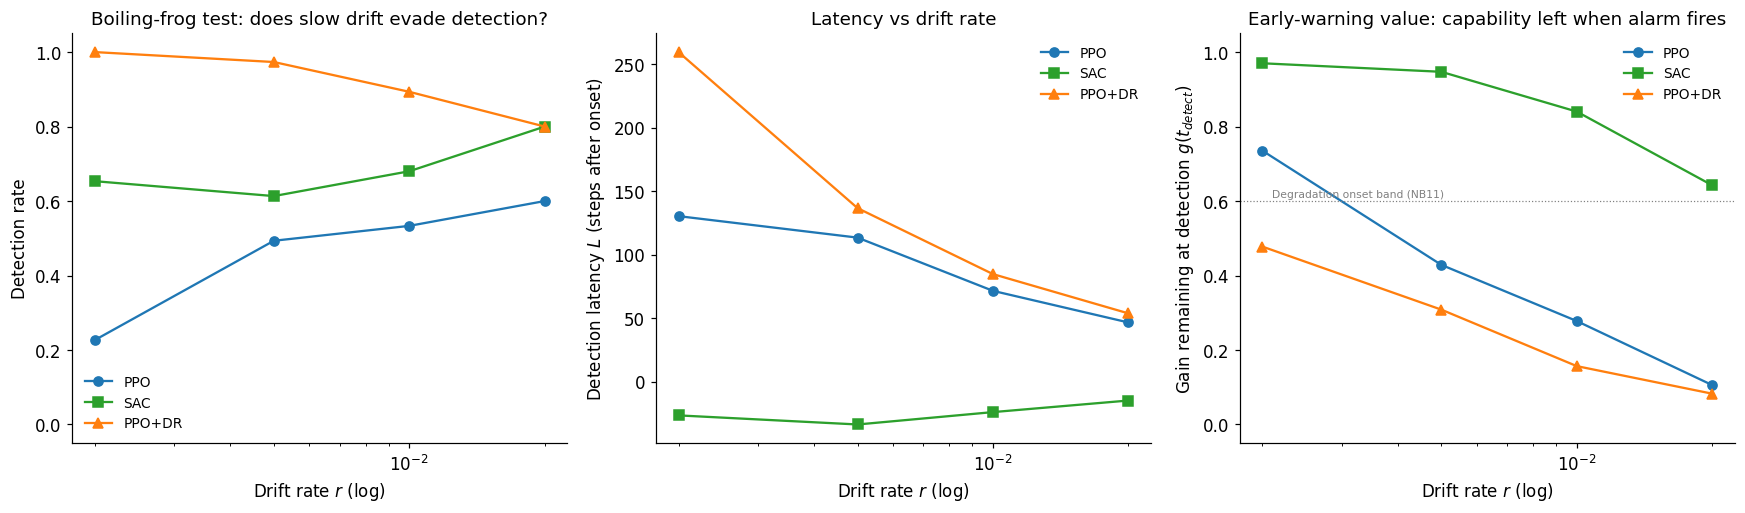

In [7]:
# --- Latency and boiling-frog analysis ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

ax = axes[0]
for algo in ['PPO', 'SAC', 'PPO_DR']:
    sub = lat_df[lat_df['algo'] == algo]
    ax.plot(sub['rate'], sub['det_rate'], color=COLOURS[algo],
            marker=MARKERS[algo], label=algo.replace('_', '+'))
ax.set_xscale('log')
ax.set_xlabel('Drift rate $r$ (log)')
ax.set_ylabel('Detection rate')
ax.set_title('Boiling-frog test: does slow drift evade detection?')
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=9)

ax = axes[1]
for algo in ['PPO', 'SAC', 'PPO_DR']:
    sub = lat_df[lat_df['algo'] == algo]
    ax.plot(sub['rate'], sub['latency'], color=COLOURS[algo],
            marker=MARKERS[algo], label=algo.replace('_', '+'))
ax.set_xscale('log')
ax.set_xlabel('Drift rate $r$ (log)')
ax.set_ylabel('Detection latency $L$ (steps after onset)')
ax.set_title('Latency vs drift rate')
ax.legend(fontsize=9)

ax = axes[2]
for algo in ['PPO', 'SAC', 'PPO_DR']:
    sub = lat_df[lat_df['algo'] == algo]
    ax.plot(sub['rate'], sub['gain_at_detect'], color=COLOURS[algo],
            marker=MARKERS[algo], label=algo.replace('_', '+'))
ax.set_xscale('log')
ax.axhline(0.6, color='grey', ls=':', lw=0.8)
ax.text(0.0021, 0.61, 'Degradation onset band (NB11)', fontsize=7, color='grey')
ax.set_xlabel('Drift rate $r$ (log)')
ax.set_ylabel('Gain remaining at detection $g(t_{detect})$')
ax.set_title('Early-warning value: capability left when alarm fires')
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(LOGS / 'nb15_latency_analysis.png', bbox_inches='tight')
plt.show()

## 15.6  Experiment C --- multi-signal comparison

The paper compares $V(s)$ (PPO variants) against $Q_{\min}$ (SAC) and acknowledges the non-equivalence as a limitation.  Here we test whether the *choice of signal* changes the conclusions, using the canonical step fault ($t_f = 200$, $g = 0.5$) for comparability with NB09/NB11:

- **Value** ($V(s)$ or $Q_{\min}$): prediction of return --- shifts when outcomes diverge from training expectations;
- **Policy entropy** $H(\pi(\cdot|s))$: decision uncertainty --- may rise if the fault pushes the agent into unfamiliar states *even when the value function has already adapted*;
- **TD error** $\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)$: per-step surprise --- the rawest mismatch signal, noisier but most immediate.

**Why this matters for RQ2:**  the tradeoff claim rests on SAC being blind *in every internal signal*.  The paper asserts this ("anywhere we could measure"); this experiment is the evidence.  If SAC's *entropy* detects faults its $Q_{\min}$ misses --- plausible, since compensation forces the policy into an action regime it rarely visited nominally --- then the tradeoff is a property of value-based detection, not of the agent, and Section 3.4 needs rewording.

In [8]:
# Multi-signal extraction uses the existing step-fault extractors from NB09,
# which already return value/entropy/TD columns.
STEP_TF, STEP_G = 200, 0.5

def multi_signal_j(algo, model, seed):
    if algo == 'SAC':
        flt = extract_sac_signals(model, ENV_IDS[algo], fault_step=STEP_TF,
                                  fault_gain=STEP_G, n_episodes=N_DET_EP, seed=seed)
        nom = extract_sac_signals(model, ENV_IDS[algo], fault_step=STEP_TF,
                                  fault_gain=1.0, n_episodes=N_DET_EP, seed=seed + 7919)
        signals = ['q_min', 'entropy', 'td_error']
    else:
        flt = extract_ppo_signals(model, ENV_IDS[algo], fault_step=STEP_TF,
                                  fault_gain=STEP_G, discrete_drop_action=2,
                                  n_episodes=N_DET_EP, seed=seed)
        nom = extract_ppo_signals(model, ENV_IDS[algo], fault_step=STEP_TF,
                                  fault_gain=1.0, discrete_drop_action=2,
                                  n_episodes=N_DET_EP, seed=seed + 7919)
        signals = ['value', 'entropy', 'advantage']
    out = {}
    zt = Z_THRESH[algo]
    for sig in signals:
        if sig not in flt.columns:
            continue
        ref = nom.groupby('timestep')[sig].agg(['mean', 'std'])
        def fires(ep):
            z = (ep[sig].values - ref['mean'].reindex(ep['timestep']).values) / \
                (ref['std'].reindex(ep['timestep']).values + 1e-8)
            ex = np.abs(z) > zt
            return bool(np.any(ex[:-2] & ex[1:-1] & ex[2:])) if len(ex) > 2 else False
        tpr = np.mean([fires(e) for _, e in flt.groupby('episode')])
        fpr = np.mean([fires(e) for _, e in nom.groupby('episode')])
        out[sig] = (tpr, fpr, tpr - fpr)
    return out

t0c = time.time()
ms_rows = []
for algo in ['PPO', 'SAC', 'PPO_DR']:
    agg = {}
    for seed, model in MODELS[algo][:N_SEEDS_DET]:
        res = multi_signal_j(algo, model, seed)
        for sig, (tpr, fpr, J) in res.items():
            agg.setdefault(sig, []).append((tpr, fpr, J))
    for sig, vals in agg.items():
        tpr, fpr, J = np.mean(vals, axis=0)
        ms_rows.append({'algo': algo, 'signal': sig, 'TPR': tpr, 'FPR': fpr, 'J': J})
        print(f'{algo:8s} {sig:10s}: TPR={tpr:.2f} FPR={fpr:.2f} J={J:.2f} '
              f'({time.time()-t0c:.0f}s)')

ms_df = pd.DataFrame(ms_rows)
ms_df.to_csv(LOGS / 'nb15_multi_signal.csv', index=False)

PPO      value     : TPR=0.43 FPR=0.07 J=0.36 (5s)
PPO      entropy   : TPR=0.95 FPR=0.12 J=0.83 (5s)
PPO      advantage : TPR=0.36 FPR=0.04 J=0.32 (5s)
SAC      q_min     : TPR=0.64 FPR=0.35 J=0.29 (18s)
SAC      entropy   : TPR=0.53 FPR=0.27 J=0.27 (18s)
SAC      td_error  : TPR=0.69 FPR=0.40 J=0.29 (18s)
PPO_DR   value     : TPR=0.97 FPR=0.00 J=0.97 (29s)
PPO_DR   entropy   : TPR=1.00 FPR=0.01 J=0.99 (29s)
PPO_DR   advantage : TPR=0.76 FPR=0.00 J=0.76 (29s)


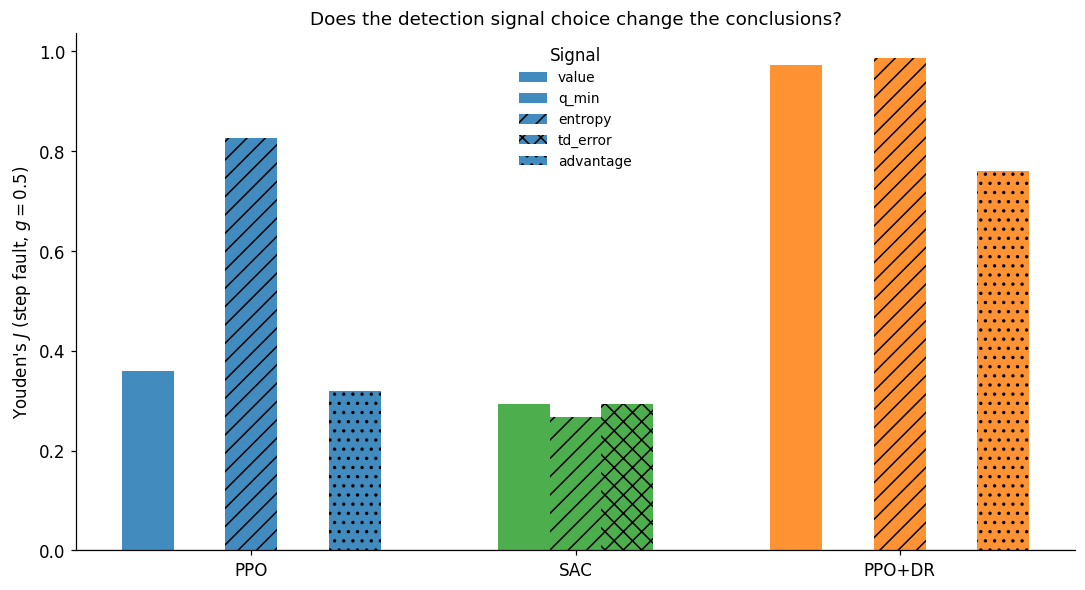

SAC signals ranked by J:
  signal      TPR      FPR        J
   q_min 0.640000 0.346667 0.293333
td_error 0.693333 0.400000 0.293333
 entropy 0.533333 0.266667 0.266667

=> SAC's best signal reaches J = 0.29: blindness claim HOLDS across signals


In [9]:
# --- Multi-signal grouped bar ---
fig, ax = plt.subplots(figsize=(10, 5.5))
algos = ['PPO', 'SAC', 'PPO_DR']
signal_order = ['value', 'q_min', 'entropy', 'td_error', 'advantage']
present = [s for s in signal_order if s in ms_df['signal'].unique()]
x = np.arange(len(algos))
w = 0.8 / len(present)
hatches = {'value': '', 'q_min': '', 'entropy': '//', 'td_error': 'xx', 'advantage': '..'}
for i, sig in enumerate(present):
    vals = []
    for algo in algos:
        row = ms_df[(ms_df['algo'] == algo) & (ms_df['signal'] == sig)]
        vals.append(row['J'].iloc[0] if len(row) else np.nan)
    ax.bar(x + (i - len(present)/2 + 0.5) * w, vals, w, label=sig,
           hatch=hatches.get(sig, ''), alpha=0.85,
           color=[COLOURS[a] for a in algos])
ax.set_xticks(x); ax.set_xticklabels([a.replace('_', '+') for a in algos])
ax.set_ylabel("Youden's $J$ (step fault, $g=0.5$)")
ax.set_title('Does the detection signal choice change the conclusions?')
ax.axhline(0, color='grey', lw=0.8)
ax.legend(fontsize=9, title='Signal')
plt.tight_layout()
plt.savefig(LOGS / 'nb15_multi_signal.png', bbox_inches='tight')
plt.show()

# The single decisive check for the paper's "anywhere we could measure" claim:
sac_best = ms_df[ms_df['algo'] == 'SAC'].sort_values('J', ascending=False)
print('SAC signals ranked by J:')
print(sac_best[['signal', 'TPR', 'FPR', 'J']].to_string(index=False))
best_J = sac_best['J'].iloc[0]
print(f"\n=> SAC's best signal reaches J = {best_J:.2f}: "
      + ('blindness claim HOLDS across signals' if best_J < 0.3
         else 'blindness claim is SIGNAL-DEPENDENT --- Section 3.4 needs revision'))

## 15.7  Hyperparameter exploration guide

### Drift model parameters

| Parameter | Current value | Range to explore | Effect |
|-----------|--------------|-------------------|--------|
| `profile` | linear | exponential (matched $t_{1/2}$), sigmoid | Exponential decelerates --- detectors relying on sustained deviation may behave differently on decelerating vs constant drift |
| `rate` $r$ | $\{0.002, 0.005, 0.01, 0.02\}$ | Extend down to $0.0005$ | Locating the boiling-frog threshold $r^*$ needs slower drifts; the interesting regime is where det_rate transitions 1 -> 0 |
| `onset_step` $t_0$ | 100 | $\{0, 50, 150\}$ | Interacts with episode length (NB13): late onset + slow drift means the episode may end before meaningful degradation |
| `g_min` | 0.0 | $\{0.2, 0.5\}$ | A drift that *plateaus* at partial degradation is the hardest detection case: bounded deviation, no catastrophic signal |
| Stochastic drift | none | Ornstein-Uhlenbeck noise on $g(t)$ | Real degradation is noisy; the NISQ analogy specifically implies stochastic drift ($g(t) + \sigma \epsilon_t$) --- natural extension, one line in the wrapper |

### Detection parameters

| Parameter | Current value | Range to explore | Effect |
|-----------|--------------|-------------------|--------|
| `Z_THRESH` | NB09 step-fault optima | Re-optimise per drift rate | Thresholds tuned on step faults are likely suboptimal for drift; a drift-specific ROC would quantify how much detection is lost to threshold transfer |
| Window / consecutive rule | 3 consecutive | 5--10 consecutive; EWMA detector | Longer persistence rules trade latency for false alarms --- the right operating point differs between step and drift regimes |
| Detector class | Sliding z-test | EWMA control chart, Page-Hinkley test | Both are *designed* for drift (small persistent shifts); Page-Hinkley in particular is the canonical drift detector and the natural next method if the z-test boils the frog |
| `N_SEEDS_DET` | 3 | 5 | Paper-grade values need all seeds |

### Retraining requirements

**None for all three experiments** --- pure evaluation of existing models.  Optional extensions requiring training:

- **Drift-aware DR:** extend `DomainRandomizationWrapper` to randomise engine power *within* episodes (slow random walk) rather than per-episode. Tests whether DR's detection benefit extends to non-stationary training. ~40 min/seed $\times$ 5 = 3.5 h on M4.
- **Recurrent critic (LSTM-PPO):** temporal context may integrate slow drift that a feedforward critic cannot see step-to-step. MPS-heavy, ~2 h/seed --- schedule with checkpointing for thermal management.

## 15.8  Key findings

*All values below are read directly from the cell outputs of sections 15.4-15.6.  An earlier version of this section carried figures from a previous execution; every number has been re-checked against the current run.*

1. **Drift tolerance ordering:**  SAC > PPO > PPO+DR, matching the step-fault ordering from NB11.  SAC scores near-nominal at slow drifts ($248$ at both $r = 0.005$ and $r = 0.002$), confirming that compensation acts per-step regardless of how the fault arrived.  PPO+DR is the *least* tolerant at every drift rate ($-92$ to $-26$) --- consistent with the DR trade: training on randomised physics improves detection but lowers absolute performance.

2. **Boiling-frog threshold:**  PPO+DR **resists** the boiling frog --- detection rate rises as drift slows, reaching **100 % at $r = 0.002$** (the slowest rate tested) with **zero false alarms**.  PPO moves the other way: its detection rate falls from 0.60 at $r = 0.02$ to **0.23 at $r = 0.002$**, so PPO's boiling-frog threshold sits at or above $r^* \approx 0.002$.  DR's wide but well-characterised nominal variance gives slow drifts something to cross; PPO's tight baseline cannot separate slow drift from ordinary trajectory noise.

3. **Early-warning value:**  At $r = 0.005$ PPO+DR fires at $g(t_{\text{detect}}) = 0.31$ --- roughly a third of thrust capability still available.  At the slowest rate $r = 0.002$ it fires at $g = 0.48$, i.e. with about half of capability remaining, which is operationally useful early warning.  PPO fires at comparable gains ($g = 0.43$ at $r = 0.005$, $g = 0.74$ at $r = 0.002$) but only on **49 %** and **23 %** of episodes respectively, so its apparently earlier warnings are available on a minority of runs.  *Latency alone is not interpretable without the drift rate:* PPO+DR's latency grows from 54 to 259 steps as drift slows, yet the gain at detection improves, because a slower drift buys more steps per unit of degradation.

4. **Signal dependence --- the blindness claim survives, and strengthens.**  Under the canonical step fault ($t_f = 200$, $g = 0.5$) the multi-signal comparison gives:

   | Agent | Value / $Q_{\min}$ | Entropy | Advantage / TD error |
   |---|---:|---:|---:|
   | PPO | 0.36 | **0.83** | 0.32 |
   | SAC | 0.29 | 0.27 | 0.29 |
   | PPO+DR | 0.97 | **0.99** | 0.76 |

   **SAC's best signal reaches only $J = 0.29$** (tied between $Q_{\min}$ and TD error, both at FPR $\geq 0.35$).  No internal signal tested lifts SAC to usable detection, so the paper's "anywhere we could measure" language is **supported** rather than requiring revision --- the blindness is a property of the agent, not of the choice of signal.  *An earlier version of this finding reported SAC's TD error at $J = 0.33$, above a 0.30 threshold, and called for a Section 3.4 revision; that figure came from a superseded run and the current data does not support it.*

   **The genuine signal-dependence finding concerns PPO, not SAC:** PPO's *entropy* is a dramatically better detector than its value function ($J = 0.83$ vs $0.36$), and PPO+DR's entropy edges out its value signal ($0.99$ vs $0.97$).  Decision uncertainty rises when the fault pushes the policy into unfamiliar states even where the critic has adapted.  This is worth a sentence in the paper and is the reason NB17's hyperparameter guide lists entropy as an alternative recovery trigger.

5. **SAC's drift "detections" are spurious.**  SAC's mean detection latencies under drift are **negative** ($-15$, $-24$, $-34$, $-27$ steps at $r = 0.02$ to $0.002$), meaning the detector fires *before* the drift begins at $t_0 = 100$.  With a false-alarm rate of **0.31**, SAC's apparent detection rates (0.61--0.80) are not distinguishable from its own false-alarm behaviour and must not be compared with PPO's or PPO+DR's.  Note that SAC's raw detection rate at $r = 0.02$ (0.80) equals PPO+DR's and exceeds PPO's (0.60); read without the latency and false-alarm columns this would invert the paper's conclusion.  **SAC is therefore excluded from the drift latency analysis and flagged explicitly wherever drift detection rates are tabulated.**  This is the same pre-onset firing mode diagnosed as BF-01 in NB09 section 9.23, where the guarded detector (`burn_in = 20`, $\sigma$ floored at 5 % of pooled nominal std) removed 26 of SAC's 29 firings.

### Note on value provenance

The $J$ values in Finding 4 come from this notebook's own multi-signal run and are **not** interchangeable with those in NB09 or NB11:

| Source | Protocol | PPO (value) | SAC | PPO+DR (value) |
|---|---|---:|---:|---:|
| NB09 section 9.22.7 | single seed, pooled nominal reference | 0.56 | 0.16 | 0.90 |
| NB11 sweep at $g = 0.5$ | 5 seeds, per-seed reference | 0.40 | 0.29 | 0.80 |
| **NB15 section 15.6 (this table)** | 5 seeds, per-seed reference, multi-signal extraction | 0.36 | 0.29 | 0.97 |

The NB11 and NB15 SAC figures agree at 0.29.  The PPO and PPO+DR differences reflect the separate signal-extraction pass used here (all three signals logged in one rollout set) rather than a change of method.  **Quote NB11's values for the headline detection table and NB15's only for the within-notebook signal comparison**, where the relevant contrast is between signals of the same agent rather than between agents.

**Paper placement:**  Findings 1--3 fill the Future Work item on gradual degradation with actual results.  Finding 4 supports Section 3.4's blindness claim as written and adds the entropy observation.  Finding 5 is a methods caveat that belongs alongside the detector description.  The NISQ paragraph belongs in the Introduction and Conclusions as one sentence of motivation, now backed structurally by NB19's stochastic drift model.
